## Analysis the Spacia result for MOSTA sample

### Import the packages

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

### Result Directory

In [2]:
RESULT_FOLDERS = {
    "Erth_Endo": "/home/akram/share/Result/Spacia_Sequence/Erth_Endo",
    "Erth_Fibo": "/home/akram/share/Result/Spacia_Sequence/Erth_Fibo",
    "Fibro_Chor_plex": "/home/akram/share/Result/Spacia_Sequence/Fibro_Chor_plex",
    "Fibro_Cranium_fibro": "/home/akram/share/Result/Spacia_Sequence/Fibro_Cranium_fibro",
    "Fibro_Endo": "/home/akram/share/Result/Spacia_Sequence/Fibro_Endo",
    "Fibro_Eryth": "/home/akram/share/Result/Spacia_Sequence/Fibro_Eryth", 
    "Fibroblast_Glia": "/home/akram/share/Result/Spacia_Sequence/Fibroblast_Glia",
    "Glia_Granule": "/home/akram/share/Result/Spacia_Sequence/Glia_Granule",
    }

OUT_DIR = "/home/akram/share/Result/Spacia_Sequence/Result"


In [3]:
PB_CUTOFF = 1e-30
PBETA_CUTOFF = 0.001 #0.001
TOP_BETA_Z_QUANTILE = 0.99
TOP_K_GENES = 5


In [4]:
meta_path = "/home/akram/share/data/Sequenceing_MOSTA/Mouse_Brain_seq_meta.txt"
meta = pd.read_csv(meta_path, sep=None, engine="python")

# infer cell-type column
celltype_col = None
preferred = {'cell_type', 'celltype', 'cell-type', 'type'}
for c in meta.columns:
    if c.lower() in preferred:
        celltype_col = c
        break
if celltype_col is None:
    for c in meta.columns:
        if 'type' in c.lower() and c.lower() not in {'cell_id', 'id', 'unnamed: 0'}:
            celltype_col = c
            break
if celltype_col is None:
    raise ValueError(f"Could not infer cell-type column from {meta.columns.tolist()}")

print("Using metadata cell-type column:", celltype_col)

Using metadata cell-type column: cell_type


In [5]:
# ensure cell_ID
if 'cell_ID' not in meta.columns:
    if 'Unnamed: 0' in meta.columns:
        meta = meta.rename(columns={'Unnamed: 0': 'cell_ID'})
    else:
        for c in meta.columns:
            if 'id' in c.lower() or 'cell' in c.lower():
                meta = meta.rename(columns={c: 'cell_ID'})
                break

meta['cell_ID'] = meta['cell_ID'].astype(str)

In [6]:
def process_folder(label, RESULT_FOLDER):

    print(f"\n=== Processing {label} ===")
    MODEL_INPUT = os.path.join(RESULT_FOLDER, "model_input")

    # ---- exp_sender ----
    with open(os.path.join(MODEL_INPUT, "exp_sender.json")) as f:
        exp_sender = json.load(f)

    # ---- sender pathways ----
    with open(os.path.join(MODEL_INPUT, "sender_pathways.json")) as f:
        sender_pathways = json.load(f)

    module_names = list(sender_pathways.keys())

    # ---- cell → sender_module ----
    rows = []
    for cid, val in exp_sender.items():
        try:
            arr = np.array(val, dtype=float)
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            imax = int(np.nanargmax(np.nanmean(arr, axis=0)))
            mod = module_names[imax] if imax < len(module_names) else f"module_{imax+1}"
        except Exception:
            mod = "module_unknown"
        rows.append((str(cid), mod))

    cell2mod = pd.DataFrame(rows, columns=["cell_ID", "sender_module"])

    # ---- load SPACIA outputs ----
    inter = pd.read_csv(os.path.join(RESULT_FOLDER, "Interactions.csv"))
    pb    = pd.read_csv(os.path.join(RESULT_FOLDER, "Pathway_betas.csv"))
    bdf   = pd.read_csv(os.path.join(RESULT_FOLDER, "B_and_FDR.csv"))

    # ---- rename ----
    inter = inter.rename(columns={
        "Unnamed: 0": "response_module",
        "Receiver": "receiver_id",
        "Sender": "sender_id"
    })
    pb = pb.rename(columns={
        "Unnamed: 0": "response_module",
        "Sender_pathway": "sender_module",
        "Beta": "beta",
        "pval": "pval",
        "pval_adj": "pval_adj"
    })
    bdf = bdf.rename(columns={
        "Unnamed: 0": "module",
        "b": "b",
        "pval": "pval"
    })

    # ---- normalize strings ----
    for df_ in [inter, pb, bdf, cell2mod]:
        for c in df_.columns:
            if df_[c].dtype == object:
                df_[c] = df_[c].astype(str).str.replace(" ", "_")

    inter['sender_id'] = inter['sender_id'].astype(str)
    inter['receiver_id'] = inter['receiver_id'].astype(str)

    # ---- attach receiver module ----
    inter = inter.merge(
        cell2mod.rename(columns={'cell_ID': 'receiver_id'}),
        on='receiver_id',
        how='left'
    )

    # ============================
    # SAME FILTERS AS FIRST CODE
    # ============================
    pb = pb[pb['pval'] < PBETA_CUTOFF]
    bdf = bdf[(bdf['b'] < 0) & (bdf['pval'] < PB_CUTOFF)]

    merged = inter.merge(
        pb[['response_module', 'sender_module', 'beta', 'pval_adj']],
        on=['response_module', 'sender_module'],
        how='left'
    )

    merged = merged.merge(
        bdf[['module', 'b']],
        left_on='response_module',
        right_on='module',
        how='inner'
    )

    merged = merged[merged['beta'].notna()]

    # ---- top 1% beta ----
    merged['beta_z'] = (merged['beta'] - merged['beta'].mean()) / merged['beta'].std()
    merged = merged[merged['beta_z'] >= merged['beta_z'].quantile(TOP_BETA_Z_QUANTILE)]

    # ---- attach cell types ----
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'sender_id', celltype_col: 'sender_type'}
        ),
        on='sender_id',
        how='left'
    )
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'receiver_id', celltype_col: 'receiver_type'}
        ),
        on='receiver_id',
        how='left'
    )

    merged['dataset'] = label

    # ============================
    # GENE–GENE EXPANSION
    # ============================
    with open(os.path.join(MODEL_INPUT, "receiver_pathways.json")) as f:
        recv_pathways = json.load(f)

    gene_rows = []
    #[:TOP_K_GENES]
    for _, r in merged.iterrows():
        s_genes = sender_pathways.get(r['sender_module'], [])[:TOP_K_GENES]
        r_genes = recv_pathways.get(r['response_module'], [])[:TOP_K_GENES]

        for sg, rg in product(s_genes, r_genes):
            gene_rows.append((
                label,
                r['sender_type'], r['receiver_type'],
                r['sender_module'], r['response_module'],
                sg, rg,
                r['beta'], r['pval_adj']
            ))

    gene_df = pd.DataFrame(
        gene_rows,
        columns=[
            "dataset",
            "sender_type", "receiver_type",
            "sender_module", "response_module",
            "sender_gene", "receiver_gene",
            "module_beta", "module_padj"
        ]
    )

    gene_df.to_csv(
        os.path.join(OUT_DIR, f"spacia_gene_pairs_filtered_{label}.csv"),
        index=False
    )

    print(f"[{label}] cells:", len(merged), " gene pairs:", len(gene_df))

    return merged, gene_df

In [7]:
# ============================
# RUN ALL DATASETS
# ============================
cell_dfs = []
gene_dfs = []

for label, folder in RESULT_FOLDERS.items():
    df_cell, df_gene = process_folder(label, folder)
    cell_dfs.append(df_cell)
    gene_dfs.append(df_gene)

df_all = pd.concat(cell_dfs, ignore_index=True)
df_genes_all = pd.concat(gene_dfs, ignore_index=True)

df_genes_all.to_csv(
    os.path.join(OUT_DIR, "spacia_gene_pairs_filtered_ALL.csv"),
    index=False
)
print("Combined cells:", df_all.shape)
print("Combined gene pairs:", df_genes_all.shape)


=== Processing Erth_Endo ===
[Erth_Endo] cells: 5012  gene pairs: 125300

=== Processing Erth_Fibo ===
[Erth_Fibo] cells: 13890  gene pairs: 347250

=== Processing Fibro_Chor_plex ===
[Fibro_Chor_plex] cells: 181  gene pairs: 4525

=== Processing Fibro_Cranium_fibro ===
[Fibro_Cranium_fibro] cells: 681  gene pairs: 17025

=== Processing Fibro_Endo ===
[Fibro_Endo] cells: 2663  gene pairs: 66575

=== Processing Fibro_Eryth ===
[Fibro_Eryth] cells: 2188  gene pairs: 54700

=== Processing Fibroblast_Glia ===
[Fibroblast_Glia] cells: 1652  gene pairs: 41300

=== Processing Glia_Granule ===
[Glia_Granule] cells: 18233  gene pairs: 455825
Combined cells: (44500, 13)
Combined gene pairs: (1112500, 9)


In [8]:
cell_types = [
    "Mixed region neuron",
    "Hindbrain glutamatergic neuron",
    "Erythrocyte",
    "Hindbrain radial glia",
    "Midbrain glutamatergic neuron",
    "Cortical or hippocampal glutamatergic neuron",
    "Ventromedial hypothalamus GABAergic neuron",
    "Forebrain glutamatergic neuroblast",
    "Mixed region GABAergic neuron",
    "Endothelial cell",
    "Cortical glutamatergic neuron",
    "Forebrain neuroblast",
    "Olfactory neuron",
    "Hindbrain glioblast",
    "Cortical intermediate progenitor",
    "Diencephalon glutamatergic neuron",
    "Dopaminergic neuron",
    "Mixed region glioblast",
    "Fibroblast",
    "Dorsal root ganglion/motor neuron",
    "Hindbrain glutamatergic neuroblast",
    "Forebrain radial glia",
    "Cajal-Rezius cell",
    "Midbrain radial glia",
    "Cranium fibroblast",
    "Hindbrain neuroblast",
    "Forebrain GABAergic neuroblast",
    "Cortical glutamatergic neuroblast",
    "Dorsal hindbrain radial glia",
    "Cerebellar granule neuroblasts",
    "Midbrain glutamatergic neuroblast",
    "Forebrain GABAergic neuron",
    "Hypothalamus neuron",
    "Choroid plexus progenitor",
    "Choroid plexus",
    "Epidermis"
]

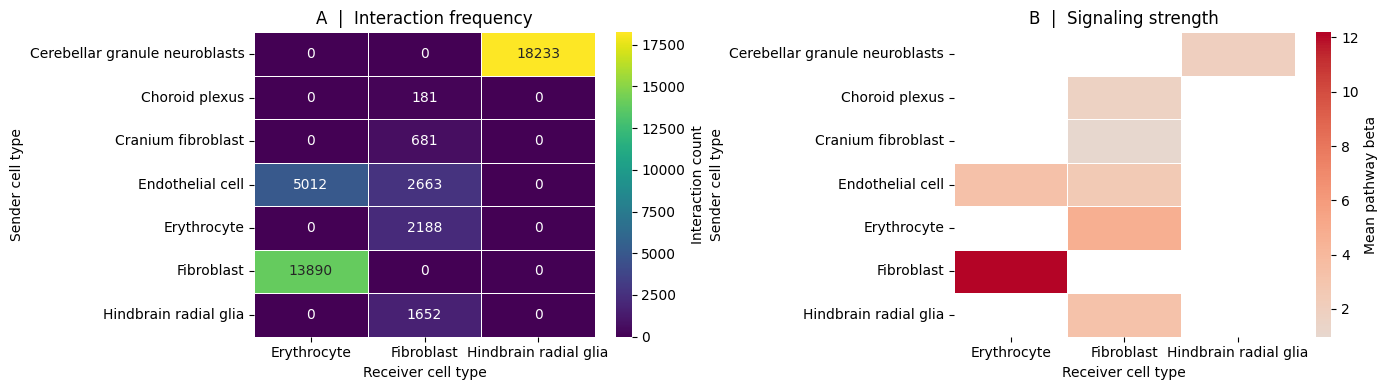

In [9]:
# Count of interactions
count_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])
    .size()
    .unstack(fill_value=0)
)
#count_mat = count_mat.reindex(index=cell_types, columns=cell_types, fill_value=0)

# Mean beta (signaling strength)
mean_beta_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])['beta']
    .mean()
    .unstack()
)

# Force same full matrix shape
#mean_beta_mat = mean_beta_mat.reindex(index=cell_types, columns=cell_types)

# Optional: mask low-count pairs in mean beta
min_n = 3
mean_beta_masked = mean_beta_mat.mask(count_mat < min_n)
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, max(4, 0.35 * count_mat.shape[0]))
)

# ============================
# Panel A — Count heatmap
# ============================
sns.heatmap(
    count_mat,
    ax=axes[0],
    cmap="viridis",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Interaction count"}
)

axes[0].set_title("A  |  Interaction frequency")
axes[0].set_xlabel("Receiver cell type")
axes[0].set_ylabel("Sender cell type")

# ============================
# Panel B — Mean beta heatmap
# ============================
sns.heatmap(
    mean_beta_masked,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean pathway beta"}
)

axes[1].set_title("B  |  Signaling strength")
axes[1].set_xlabel("Receiver cell type")
axes[1].set_ylabel("Sender cell type")  # shared y-axis

plt.tight_layout()
plt.show()



In [10]:
df = df = pd.read_csv(f"{OUT_DIR}/spacia_gene_pairs_filtered_ALL.csv")
df_unique = df.drop_duplicates(subset=["sender_gene", "receiver_gene"])


df_unique.to_csv(f"{OUT_DIR}/spacia_gene_pairs_unique_ALL.csv", index=False)

print("Unique directed LR pairs:", len(df_unique))
pairs = df_unique[['sender_gene', 'receiver_gene']]

for _, row in df_unique.sort_values(['sender_gene','receiver_gene']).iterrows():
    print(f"{row['sender_gene']} → {row['receiver_gene']}")

Unique directed LR pairs: 383
1110008P14Rik → Aplp2
1110008P14Rik → Mif
1110008P14Rik → Ndufa12
1110008P14Rik → Tcf25
1110008P14Rik → Tpi1
4732471J01Rik → Apbb1
4732471J01Rik → Cox7a2
4732471J01Rik → Rps15a
4732471J01Rik → Rps28
4732471J01Rik → Scg3
Acot13 → Ap2b1
Acot13 → Creg2
Acot13 → Dalrd3
Acot13 → Itpka
Acot13 → Kcnf1
Acot13 → March6
Acot13 → Ndrg3
Acot13 → Prkcg
Acot13 → Timp2
Acot13 → Wdr6
Arhgap31 → Aes
Arhgap31 → Ap2b1
Arhgap31 → Atp5d
Arhgap31 → Hnrnpa3
Arhgap31 → Pcp4
Bcas1 → Cldn11
Bcas1 → Mbp
Bcas1 → Mobp
Bcas1 → Plekhb1
Bcas1 → Plp1
Bsn → Aplp2
Bsn → Mif
Bsn → Ndufa12
Bsn → Tcf25
Bsn → Tpi1
Calb1 → Ap2b1
Calb1 → Creg2
Calb1 → Dalrd3
Calb1 → Itpka
Calb1 → Kcnf1
Calb1 → March6
Calb1 → Ndrg3
Calb1 → Prkcg
Calb1 → Timp2
Calb1 → Wdr6
Calm3 → Atp5a1
Calm3 → Kirrel3
Calm3 → Nptn
Calm3 → Rnf187
Calm3 → Stoml1
Car2 → Cnp
Car2 → Mal
Car2 → Mbp
Car2 → Mobp
Car2 → Plp1
Cd81 → Creg2
Cd81 → Itpka
Cd81 → Kcnf1
Cd81 → March6
Cd81 → Ndrg3
Cldn11 → Clu
Cldn11 → Cnp
Cldn11 → Fau
Cldn11 → F

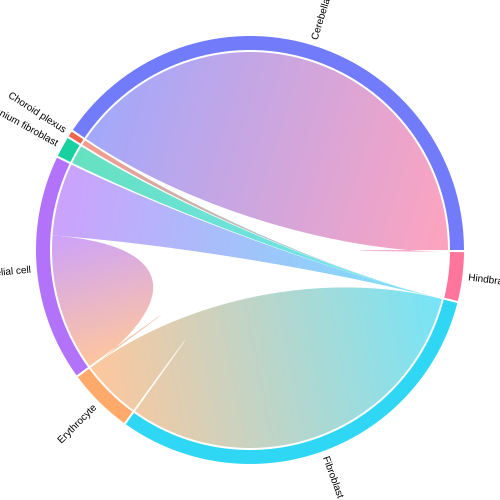

In [11]:
import os
import pandas as pd
import openchord as ocd

# 1️⃣ Generate matrices
count_mat = df_all.groupby(['sender_type', 'receiver_type']).size().unstack(fill_value=0)
sum_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].sum().unstack(fill_value=0)
mean_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].mean().unstack()

# 2️⃣ Save matrices
count_mat.to_csv(os.path.join(OUT_DIR, "matrix_count_combined.csv"))
sum_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_sum_beta_combined.csv"))
mean_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_mean_beta_combined.csv"))

# 3️⃣ Prepare labels in consistent order
senders = list(count_mat.index)
receivers = list(count_mat.columns)

# Combine sender and receiver labels for chord diagram labels
labels = senders + [r for r in receivers if r not in senders]

# 4️⃣ Build adjacency matrix for chord diagram
import numpy as np

# Initialize square matrix with zeros
size = len(labels)
adjacency_matrix = np.zeros((size, size))

# Fill in sender->receiver values in appropriate matrix positions
for i, sender in enumerate(senders):
    for j, receiver in enumerate(receivers):
        sender_idx = labels.index(sender)
        receiver_idx = labels.index(receiver)
        adjacency_matrix[sender_idx, receiver_idx] = count_mat.loc[sender, receiver]

# 5️⃣ Create chord diagram
fig = ocd.Chord(adjacency_matrix.tolist(), labels)

# 6️⃣ Optional: Set colors (make sure you have enough for all labels)
fig.colormap = [
    '#636EFA', '#EF553B', '#00CC96', '#AB63FA',
    '#FFA15A', '#19D3F3', '#FF6692', '#B6E880',
    '#FF97FF', '#FECB52', '#8A2BE2', '#FF4500', '#2E8B57'
][:len(labels)]  # truncate or extend as needed

# 7️⃣ Show the plot
fig.show()


### cell-type interaction strength based on significant Spacia interactions

In [12]:
# Save Spacia final cell-type interaction matrix
spacia_mat = mean_beta_masked.copy()
spacia_mat.to_csv("/home/akram/share/Result/Spacia_Sequence/Result/Spacia_celltype_matrix.csv")
print("Saved: Spacia_celltype_matrix.csv")

Saved: Spacia_celltype_matrix.csv
